DSCI 552 Homework 4
===================

- Name: Umaeshwer Shankar
- GitHub Username: umaeshwer
- USD ID: 7601-5514-88

# Importing Libraries

In [168]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import bootstrapped.bootstrap as bs
import bootstrapped.stats_functions as bs_stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.utils import resample
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB


## 1. Time Series Classification Part 1: Feature Creation/Extraction

(a) Download the AReM data. The dataset contains 7 folders that represent seven types of activities. In
each folder, there are multiple files each of which represents an instant of a human
performing an activity.1 Each file containis 6 time series collected from activities
of the same person, which are called avg rss12, var rss12, avg rss13, var rss13,
vg rss23, and ar rss23. There are 88 instances in the dataset, each of which con-
tains 6 time series and each time series has 480 consecutive values.

In [169]:
root_path = '../data/AReM'

folders = [f for f in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, f))]
print(f"Folder names: {folders}")

Folder names: ['bending1', 'walking', 'bending2', 'standing', 'sitting', 'lying', 'cycling']


(b) Keep datasets 1 and 2 in folders bending1 and bending 2, as well as datasets 1,
2, and 3 in other folders as test data and other datasets as train data.

In [170]:
train_files, test_files = [], []

def load_files(folder_path):
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.csv'):
                if root.split('/')[3] in ['bending1', 'bending2'] and file in ['dataset1.csv', 'dataset2.csv']:
                    test_files.append(root + '/' + file)
                elif root.split('/')[3] not in ['bending1', 'bending2'] and file in ['dataset1.csv', 'dataset2.csv', 'dataset3.csv']:
                    test_files.append(root + '/' + file)
                else:
                    train_files.append(root + '/' + file)
    return train_files, test_files

train_files, test_files = load_files(root_path)

print(f"Train files: {train_files}")
print(f"Test files: {test_files}")

Train files: ['../data/AReM/bending1/dataset7.csv', '../data/AReM/bending1/dataset6.csv', '../data/AReM/bending1/dataset4.csv', '../data/AReM/bending1/dataset5.csv', '../data/AReM/bending1/dataset3.csv', '../data/AReM/walking/dataset7.csv', '../data/AReM/walking/dataset6.csv', '../data/AReM/walking/dataset4.csv', '../data/AReM/walking/dataset5.csv', '../data/AReM/walking/dataset10.csv', '../data/AReM/walking/dataset11.csv', '../data/AReM/walking/dataset13.csv', '../data/AReM/walking/dataset12.csv', '../data/AReM/walking/dataset15.csv', '../data/AReM/walking/dataset14.csv', '../data/AReM/walking/dataset8.csv', '../data/AReM/walking/dataset9.csv', '../data/AReM/bending2/dataset6.csv', '../data/AReM/bending2/dataset4.csv', '../data/AReM/bending2/dataset5.csv', '../data/AReM/bending2/dataset3.csv', '../data/AReM/standing/dataset7.csv', '../data/AReM/standing/dataset6.csv', '../data/AReM/standing/dataset4.csv', '../data/AReM/standing/dataset5.csv', '../data/AReM/standing/dataset10.csv', '..

(c) Feature Extraction

Classification of time series usually needs extracting features from them. In this
problem, we focus on time-domain features.

i. Research what types of time-domain features are usually used in time series
classification and list them (examples are minimum, maximum, mean, etc).

Answer:

- Mean
- Median
- Minimum
- Maximum
- Standard Deviation
- 1st quartile
- 3rd quartile
- Interquartile range
- Lag

ii. Extract the time-domain features minimum, maximum, mean, median, standard deviation, first quartile, and third quartile for all of the 6 time series
in each instance. You are free to normalize/standardize features or use them
directly.

In [171]:
column_names = ['# Columns: time','avg_rss12','var_rss12','avg_rss13','var_rss13','avg_rss23','var_rss23']
time_series_columns = column_names[1:]
feature_columns = ['mean', 'std', 'min', '1st_quart', 'median', '3rd_quart', 'max']


def load_data(file_list, segment_count=1):
    df_dict = {}
    labels = []
    for file in file_list:
        folder = os.path.dirname(file)
        label = os.path.split(folder)[-1]
        
        if file == '../data/AReM/bending2/dataset4.csv':
            df = pd.read_csv('../data/AReM/bending2/dataset4.csv', skiprows=5, sep='\s+',header=None, on_bad_lines='skip')
        else:
            df = pd.read_csv(file, skiprows=5, header=None, on_bad_lines='skip')

        df.columns = column_names

        segmented_dfs = []
        if segment_count > 1:
            segment_size = len(df) // segment_count
            for seg in range(segment_count):
                seg_start = seg * segment_size
                seg_end = (seg + 1) * segment_size if seg < segment_count - 1 else len(df)
                seg_df = df.iloc[seg_start:seg_end].copy()
                seg_df.columns = column_names
                segmented_dfs.append(seg_df)
        else:
            segmented_dfs = [df]

        # For each file, collect all segment features into a single row
        row_features = {}
        for seg_idx, seg_df in enumerate(segmented_dfs):
            desc = seg_df.describe().drop('count').drop(columns='# Columns: time').T
            desc.columns = feature_columns
            desc = desc.to_dict()
            for col in time_series_columns:
                for feat in feature_columns:
                    key = f"{col}{seg_idx}_{feat}" if segment_count > 1 else f"{col}_{feat}"
                    row_features[key] = desc[feat][col]
        # Append features for this file
        for k, v in row_features.items():
            if k in df_dict:
                df_dict[k].append(v)
            else:
                df_dict[k] = [v]
        labels.append(label)

    df_dict['label'] = labels
    return pd.DataFrame(df_dict)

<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/5c/3qs4gb0n2jjb1nf6m8w53dvh0000gn/T/ipykernel_5020/2719898776.py:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv('../data/AReM/bending2/dataset4.csv', skiprows=5, sep='\s+',header=None, on_bad_lines='skip')


In [172]:
"""
Errors encountered:

1. ../data/AReM/bending2/dataset4.csv: Different delimiter
2. Skipping bad lines in some files due to inconsistent formatting
"""

print("Loading training data...")
train_df = load_data(train_files)

display(train_df)

Loading training data...


,avg_rss12_mean,avg_rss12_std,avg_rss12_min,avg_rss12_1st_quart,avg_rss12_median,avg_rss12_3rd_quart,avg_rss12_max,var_rss12_mean,var_rss12_std,var_rss12_min,...,avg_rss23_3rd_quart,avg_rss23_max,var_rss23_mean,var_rss23_std,var_rss23_min,var_rss23_1st_quart,var_rss23_median,var_rss23_3rd_quart,var_rss23_max,label
0,43.969125,1.618364,36.25,43.310,44.50,44.67,48.00,0.413125,0.263111,0.0,...,23.7500,30.75,0.555312,0.487826,0.0,0.0000,0.490,0.830,2.96,bending1
1,43.454958,1.386098,37.00,42.500,43.25,45.00,48.00,0.378083,0.315566,0.0,...,24.0000,33.50,0.679646,0.622534,0.0,0.4300,0.500,0.870,5.26,bending1
2,42.179812,3.670666,33.00,39.150,43.50,45.00,47.75,0.696042,0.630860,0.0,...,36.3300,38.67,0.613521,0.524317,0.0,0.0000,0.500,1.000,2.18,bending1
3,41.678063,2.243490,33.00,41.330,41.75,42.75,45.75,0.535979,0.405469,0.0,...,31.2500,37.50,0.383292,0.389164,0.0,0.0000,0.430,0.500,1.79,bending1
4,43.954500,1.558835,35.00,43.000,44.33,45.00,47.40,0.426250,0.338690,0.0,...,36.5000,38.50,0.493292,0.513506,0.0,0.0000,0.430,0.940,1.79,bending1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,35.752354,4.614802,18.50,33.000,36.00,39.33,44.25,3.328104,2.140576,0.0,...,18.0625,24.33,3.069667,1.748326,0.0,1.7975,2.770,4.060,9.39,cycling
65,37.177042,3.581301,24.25,34.500,36.25,40.25,45.00,2.374208,1.601799,0.0,...,21.7500,25.50,2.921729,1.852600,0.0,1.5000,2.500,3.900,9.34,cycling
66,36.248768,3.824632,23.33,33.415,36.75,39.25,43.50,2.737307,2.093999,0.0,...,21.0000,27.00,3.532463,1.965267,0.0,2.1700,3.110,4.625,11.15,cycling
67,36.957458,3.434863,26.25,34.500,36.29,40.25,44.25,2.420083,1.724901,0.0,...,18.2500,22.25,2.934625,1.631380,0.0,1.6600,2.525,4.030,8.34,cycling


In [173]:
print("Loading test data...")
test_df = load_data(test_files)

display(test_df)

Loading test data...


,avg_rss12_mean,avg_rss12_std,avg_rss12_min,avg_rss12_1st_quart,avg_rss12_median,avg_rss12_3rd_quart,avg_rss12_max,var_rss12_mean,var_rss12_std,var_rss12_min,...,avg_rss23_3rd_quart,avg_rss23_max,var_rss23_mean,var_rss23_std,var_rss23_min,var_rss23_1st_quart,var_rss23_median,var_rss23_3rd_quart,var_rss23_max,label
0,40.624792,1.476967,37.25,39.2500,40.500,42.0000,45.00,0.358604,0.322605,0.0,...,36.0000,38.25,0.570583,0.582915,0.0,0.0000,0.430,1.300,1.92,bending1
1,42.812812,1.435550,38.00,42.0000,42.500,43.6700,45.67,0.372437,0.289158,0.0,...,34.5000,38.50,0.571083,0.601010,0.0,0.0000,0.430,1.300,3.11,bending1
2,34.227771,4.889576,19.33,30.5000,35.500,37.7500,43.50,3.995729,2.271102,0.0,...,18.6700,26.00,3.394125,1.792090,0.0,2.1050,3.100,4.425,9.74,walking
3,33.509729,4.850923,12.50,30.5000,34.125,36.7500,45.00,4.450771,2.338685,0.0,...,18.7500,25.00,3.378479,1.787360,0.0,2.0600,3.085,4.440,8.96,walking
4,34.660583,5.315110,15.00,31.0000,35.000,38.2500,46.75,4.200896,2.480206,0.0,...,18.5000,24.50,3.244396,1.630983,0.0,2.1200,3.000,4.240,8.99,walking
5,24.562958,3.737514,12.75,23.1875,24.250,26.5000,51.00,0.590833,0.837408,0.0,...,27.0000,30.00,0.700188,0.693720,0.0,0.4300,0.500,0.870,4.97,bending2
6,27.464604,3.583582,0.00,25.5000,28.000,30.0000,42.75,0.449708,0.767197,0.0,...,20.7500,33.00,1.122125,1.012342,0.0,0.4700,0.830,1.300,6.76,bending2
7,44.334729,2.476940,33.33,42.2500,45.000,46.5000,48.00,0.432958,0.370591,0.0,...,17.7500,23.00,0.933000,0.673609,0.0,0.4700,0.830,1.250,5.02,standing
8,43.174938,1.989052,35.50,42.5000,43.670,44.5000,46.25,0.506583,0.307413,0.0,...,16.5000,21.25,0.911979,0.666161,0.0,0.4700,0.830,1.220,5.72,standing
9,42.760562,3.398919,32.75,41.3300,44.500,45.3725,47.00,0.486167,0.446511,0.0,...,18.5650,21.33,0.842271,0.722165,0.0,0.4300,0.710,1.090,5.73,standing


iii. Estimate the standard deviation of each of the time-domain features you
extracted from the data. Then, use Python’s bootstrapped or any other
method to build a 90% bootsrap confidence interval for the standard deviation
of each feature.

In [174]:
train_df.describe().loc['std']

avg_rss12_mean         4.917692
avg_rss12_std          1.758670
avg_rss12_min          8.794295
avg_rss12_1st_quart    5.731647
avg_rss12_median       4.956111
avg_rss12_3rd_quart    4.783645
avg_rss12_max          4.429182
var_rss12_mean         1.600701
var_rss12_std          0.902808
var_rss12_min          0.000000
var_rss12_1st_quart    0.952201
var_rss12_median       1.436960
var_rss12_3rd_quart    2.158416
var_rss12_max          5.147841
avg_rss13_mean         3.863097
avg_rss13_std          0.995959
avg_rss13_min          3.053869
avg_rss13_1st_quart    4.145255
avg_rss13_median       3.845730
avg_rss13_3rd_quart    3.946023
avg_rss13_max          4.759853
var_rss13_mean         1.179861
var_rss13_std          0.473576
var_rss13_min          0.000000
var_rss13_1st_quart    0.842501
var_rss13_median       1.150092
var_rss13_3rd_quart    1.566564
var_rss13_max          2.302408
avg_rss23_mean         5.120426
avg_rss23_std          1.057998
avg_rss23_min          5.368786
avg_rss2

In [175]:
for col in train_df.columns:
    if col != 'label':
        ci = bs.bootstrap(np.array(train_df[col]), stat_func=bs_stats.std, alpha=0.1)
        print(f"90% CI for {col}: {ci}")

90% CI for avg_rss12_mean: 4.881926151830011    (4.386337139524162, 5.471302976388562)
90% CI for avg_rss12_std: 1.7458793319878128    (1.5648383773011767, 1.9562786541337318)
90% CI for avg_rss12_min: 8.730335507644277    (7.476882194936977, 9.972149084295241)
90% CI for avg_rss12_1st_quart: 5.689961410573205    (5.215050790503617, 6.266894300703923)
90% CI for avg_rss12_median: 4.920065980691552    (4.383999641335382, 5.544305962140868)
90% CI for avg_rss12_3rd_quart: 4.748854525045172    (4.000800269013663, 5.603999564212009)
90% CI for avg_rss12_max: 4.396968872496197    (3.4315505117071066, 5.546904752174575)
90% CI for var_rss12_mean: 1.5890592339540666    (1.451894419797322, 1.7833830511855724)
90% CI for var_rss12_std: 0.8962421917100799    (0.8354968141601934, 0.9878312097071491)
90% CI for var_rss12_min: 0.0    (0.0, 0.0)
90% CI for var_rss12_1st_quart: 0.9452754510876189    (0.849257939229785, 1.0759048945021288)
90% CI for var_rss12_median: 1.4265088556429972    (1.28473350

iv. Use your judgement to select the three most important time-domain features
(one option may be min, mean, and max).

Answer:

To select the best features we need to consider the effect size (standard deviation) in this case and the range of the interval (smaller the range, the better it is). Based on these factors the three important features are:

- mean
- median
- 1st_quart

## 2. Time Series Classification Part 2: Binary and Multiclass Classification

### (a) Binary Classification Using Logistic Regression

i. Assume that you want to use the training set to classify bending from other
activities, i.e. you have a binary classification problem. Depict scatter plots
of the features you specified in 1(c)iv extracted from time series 1, 2, and 6 of
each instance, and use color to distinguish bending vs. other activities. (See
p. 129 of the textbook).

In [176]:
# extract binary label for training data
bending_train_data = train_df.copy()
bending_train_data['label'] = bending_train_data['label'].apply(lambda x: 1 if 'bending' in x else 0)
display(bending_train_data)

,avg_rss12_mean,avg_rss12_std,avg_rss12_min,avg_rss12_1st_quart,avg_rss12_median,avg_rss12_3rd_quart,avg_rss12_max,var_rss12_mean,var_rss12_std,var_rss12_min,...,avg_rss23_3rd_quart,avg_rss23_max,var_rss23_mean,var_rss23_std,var_rss23_min,var_rss23_1st_quart,var_rss23_median,var_rss23_3rd_quart,var_rss23_max,label
0,43.969125,1.618364,36.25,43.310,44.50,44.67,48.00,0.413125,0.263111,0.0,...,23.7500,30.75,0.555312,0.487826,0.0,0.0000,0.490,0.830,2.96,1
1,43.454958,1.386098,37.00,42.500,43.25,45.00,48.00,0.378083,0.315566,0.0,...,24.0000,33.50,0.679646,0.622534,0.0,0.4300,0.500,0.870,5.26,1
2,42.179812,3.670666,33.00,39.150,43.50,45.00,47.75,0.696042,0.630860,0.0,...,36.3300,38.67,0.613521,0.524317,0.0,0.0000,0.500,1.000,2.18,1
3,41.678063,2.243490,33.00,41.330,41.75,42.75,45.75,0.535979,0.405469,0.0,...,31.2500,37.50,0.383292,0.389164,0.0,0.0000,0.430,0.500,1.79,1
4,43.954500,1.558835,35.00,43.000,44.33,45.00,47.40,0.426250,0.338690,0.0,...,36.5000,38.50,0.493292,0.513506,0.0,0.0000,0.430,0.940,1.79,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,35.752354,4.614802,18.50,33.000,36.00,39.33,44.25,3.328104,2.140576,0.0,...,18.0625,24.33,3.069667,1.748326,0.0,1.7975,2.770,4.060,9.39,0
65,37.177042,3.581301,24.25,34.500,36.25,40.25,45.00,2.374208,1.601799,0.0,...,21.7500,25.50,2.921729,1.852600,0.0,1.5000,2.500,3.900,9.34,0
66,36.248768,3.824632,23.33,33.415,36.75,39.25,43.50,2.737307,2.093999,0.0,...,21.0000,27.00,3.532463,1.965267,0.0,2.1700,3.110,4.625,11.15,0
67,36.957458,3.434863,26.25,34.500,36.29,40.25,44.25,2.420083,1.724901,0.0,...,18.2500,22.25,2.934625,1.631380,0.0,1.6600,2.525,4.030,8.34,0


<Figure size 1200x1000 with 0 Axes>

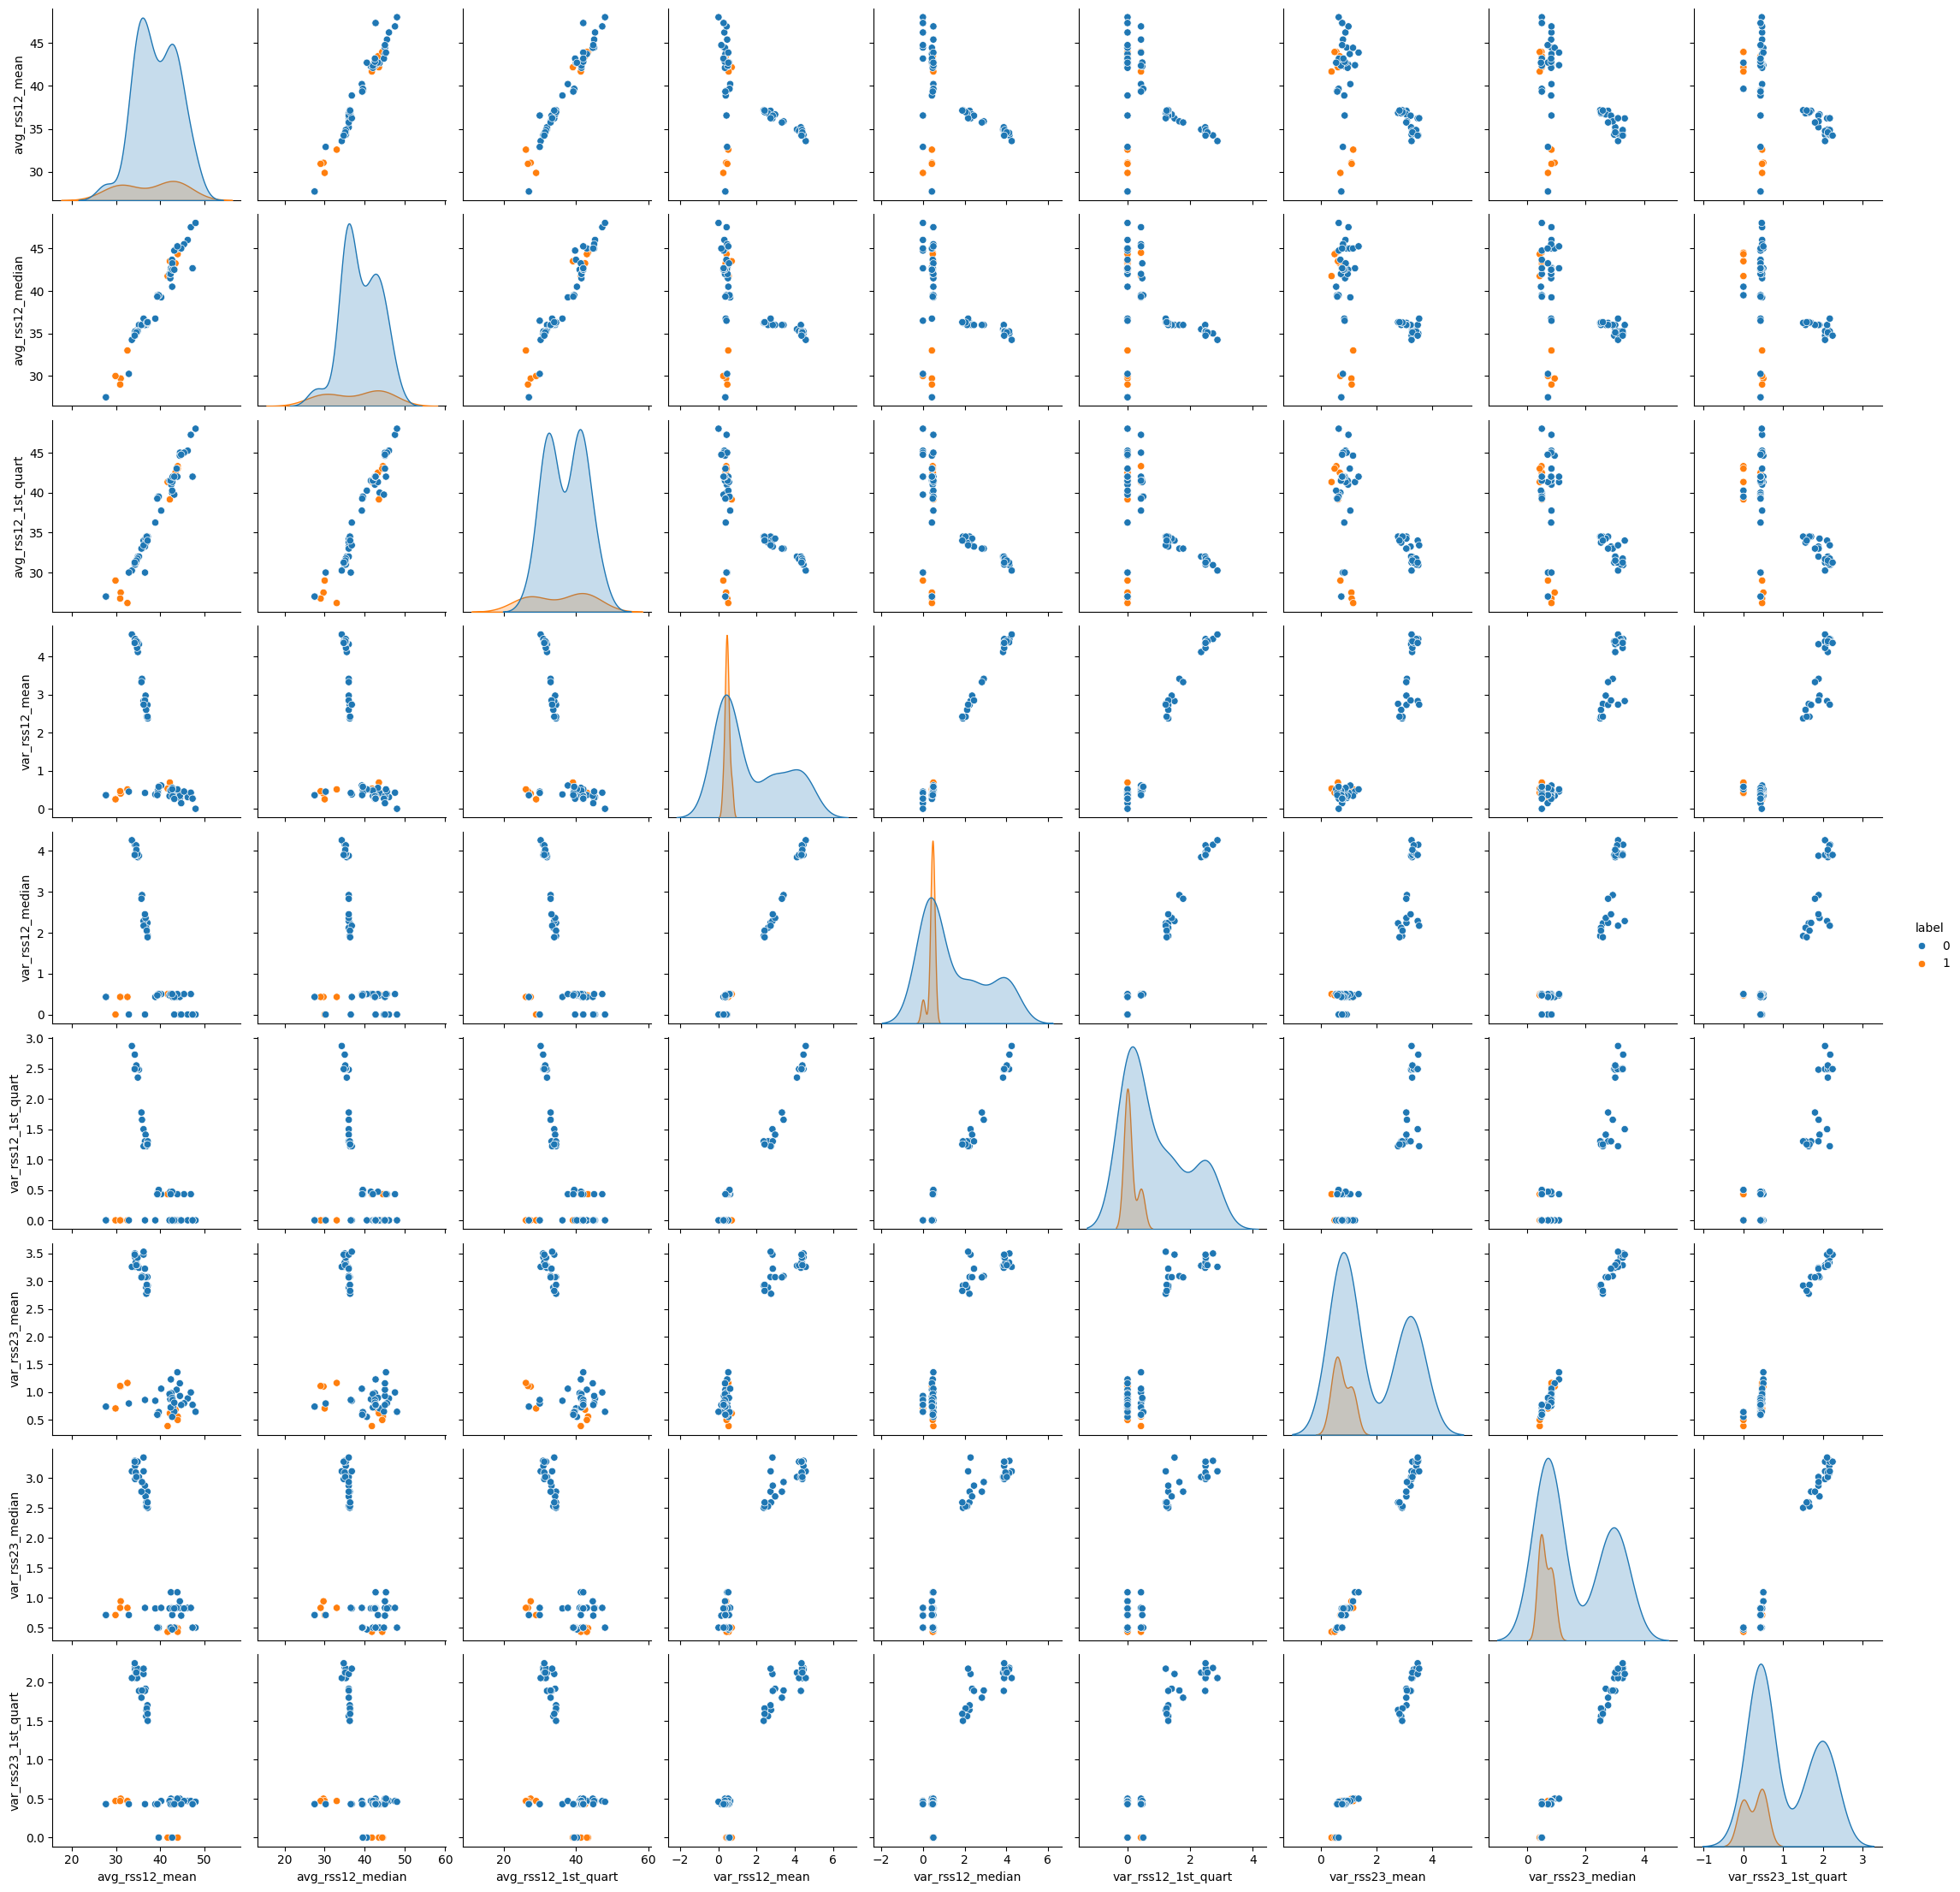

In [177]:
# function for getting scatterplots for selected features
def get_scatterplots(df, indices, features):
    selected_features = [f"{col}_{feat}" for col in indices for feat in features]
    selected_data = df[selected_features + ['label']]
    fig = plt.figure(figsize=(12, 10))
    sns.pairplot(selected_data, hue='label')
    plt.show()

get_scatterplots(bending_train_data, ['avg_rss12','var_rss12','var_rss23'], ['mean', 'median', '1st_quart'])

ii. Break each time series in your training set into two (approximately) equal
length time series. Now instead of 6 time series for each of the training
instances, you have 12 time series for each training instance. Repeat the
experiment in 2(a)i, i.e depict scatter plots of the features extracted from both
parts of the time series 1,2, and 6. Do you see any considerable diﬀerence in
the results with those of 2(a)i?

In [178]:
train_segmented_df = load_data(train_files, segment_count=2)

# extract binary label for training data
bending_train_data = train_segmented_df.copy()
bending_train_data['label'] = bending_train_data['label'].apply(lambda x: 1 if 'bending' in x else 0)
display(bending_train_data)

,avg_rss120_mean,avg_rss120_std,avg_rss120_min,avg_rss120_1st_quart,avg_rss120_median,avg_rss120_3rd_quart,avg_rss120_max,var_rss120_mean,var_rss120_std,var_rss120_min,...,avg_rss231_3rd_quart,avg_rss231_max,var_rss231_mean,var_rss231_std,var_rss231_min,var_rss231_1st_quart,var_rss231_median,var_rss231_3rd_quart,var_rss231_max,label
0,43.486208,1.281976,36.67,42.3300,43.71,44.50,45.00,0.378667,0.284434,0.0,...,23.5000,26.00,0.585750,0.487918,0.0,0.4225,0.500,0.8300,2.96,1
1,44.117042,1.359836,39.00,43.5000,45.00,45.00,48.00,0.250042,0.314099,0.0,...,23.7500,26.00,0.543875,0.473445,0.0,0.4300,0.500,0.7100,4.06,1
2,43.278875,3.473355,33.75,42.0000,45.00,45.25,47.75,0.673292,0.634285,0.0,...,33.7500,38.50,0.586083,0.491873,0.0,0.0000,0.470,0.8700,2.18,1
3,41.621208,3.118644,33.00,39.6525,42.33,44.25,45.75,0.623083,0.489595,0.0,...,30.5625,36.00,0.347500,0.363144,0.0,0.0000,0.430,0.5000,1.50,1
4,44.057167,1.556971,36.50,43.2500,44.50,45.00,46.50,0.381042,0.329540,0.0,...,36.2500,38.25,0.388333,0.478528,0.0,0.0000,0.000,0.7100,1.50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,35.692167,4.643595,20.00,33.0000,35.50,39.25,44.25,3.324208,2.162230,0.0,...,18.2500,24.33,2.966917,1.712062,0.0,1.8525,2.590,3.7400,8.81,0
65,36.954208,3.772836,24.25,34.2500,36.00,40.25,45.00,2.392667,1.523329,0.0,...,21.6700,24.50,2.838083,1.890755,0.0,1.3825,2.450,3.8325,9.34,0
66,36.337908,3.655379,27.00,33.6700,36.75,39.00,42.67,2.698494,2.019077,0.0,...,21.0000,26.67,3.533958,1.994636,0.0,2.1700,3.085,4.5075,11.15,0
67,36.865417,3.462793,26.25,34.3100,36.25,40.00,43.40,2.387250,1.625296,0.0,...,18.0000,21.25,2.904458,1.609793,0.0,1.6900,2.570,3.7700,8.34,0


<Figure size 1200x1000 with 0 Axes>

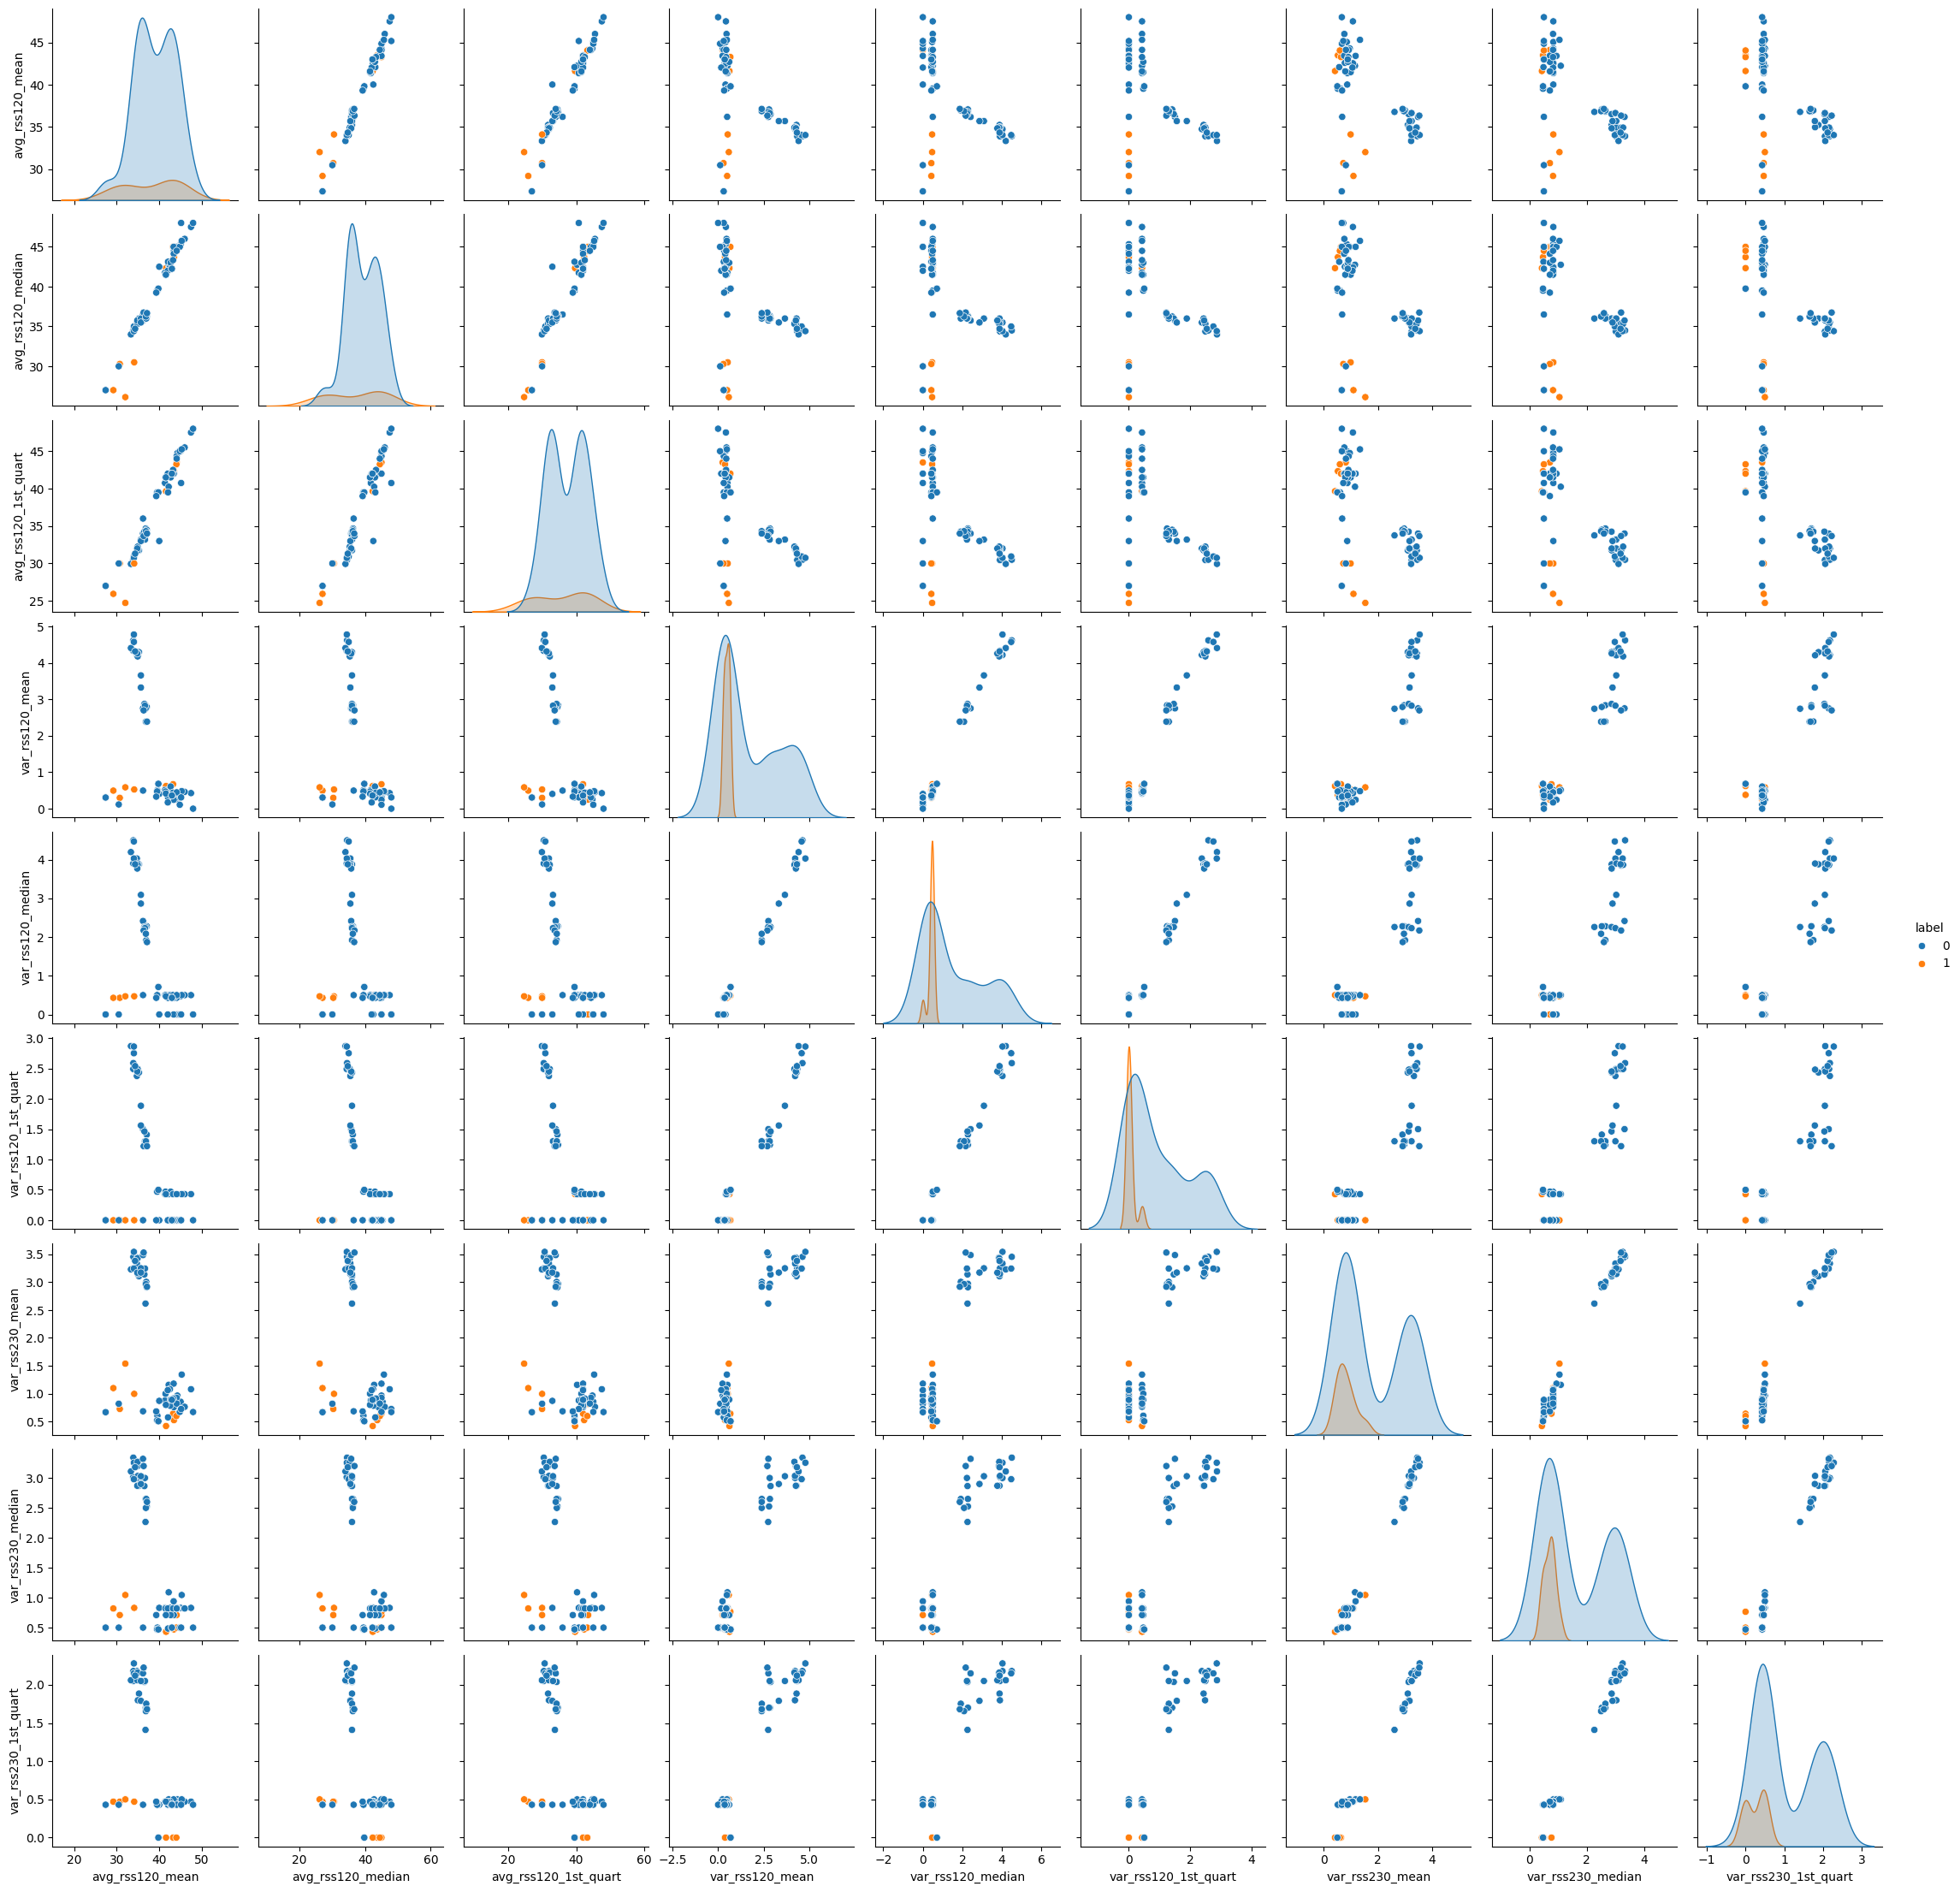

In [179]:
get_scatterplots(bending_train_data, ['avg_rss120','var_rss120','var_rss230'], ['mean', 'median', '1st_quart'])

The distributions are similar but different from the previous case

iii. Break each time series in your training set into l ∈{1,2,...,20}time series
of approximately equal length and use logistic regression5 to solve the binary
classification problem, using time-domain features. Remember that breaking
each of the time series does not change the number of instances. It only
changes the number of features for each instance. Calculate the p-values for
your logistic regression parameters in each model corresponding to each value
of l and refit a logistic regression model using your pruned set of features.6
Alternatively, you can use backward selection using sklearn.feature selection
or glm in R. Use 5-fold cross-validation to determine the best value of the pair
(l,p), where pis the number of features used in recursive feature elimination.
Explain what the right way and the wrong way are to perform cross-validation
in this problem.7 Obviously, use the right way! Also, you may encounter the
problem of class imbalance, which may make some of your folds not having
any instances of the rare class. In such a case, you can use stratified cross
validation. Research what it means and use it if needed.

In the following, you can see an example of applying Python’s Recursive Feature Elimination, which is a backward selection algorithm, to logistic regression.

```
# Recursive Feature Elimination
from sklearn import datasets
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
# load the iris dataset
dataset = datasets.load_iris()
# create a base classifier used to evaluate a subset of attributes
model = LogisticRegression()
# create the RFE model and select 3 attributes
rfe = RFE(model, 3)
rfe = rfe.fit(dataset.data, dataset.target)
# summarize the selection of the attributes
print(rfe.support_)
print(rfe.ranking_)
```

In [180]:
def LR_helper(train_files, num_fold, l, oversample):
    # load data with given value of l
    train_df = load_data(train_files, segment_count=l)
    train_df['label'] = train_df['label'].apply(lambda x: 1 if 'bending' in x else 0)
    
    # oversample the data if required
    if oversample:
        num_label_0 = train_df.loc[train_df['label'] == 0].shape[0]
        num_label_1 = train_df.loc[train_df['label'] == 1].shape[0]
        minor_count = min(num_label_0, num_label_1)
        major_count = max(num_label_0, num_label_1)
        minor_label = 1 if num_label_0 > num_label_1 else 0
        minor = train_df.loc[train_df['label'] == minor_label]
        major = train_df.loc[train_df['label'] != minor_label]
        minor = resample(minor, replace=True, random_state=60,
                         n_samples=major_count)
        train_df = pd.concat([major, minor])
        print("Oversample the minority from {} to {} samples".format(minor_count, 
                                                                     major_count))
    
    # split features and labels
    trainX, trainY = train_df.iloc[:, :-1], train_df.iloc[:, -1]
    validator = StratifiedKFold(n_splits=num_fold, shuffle=True, random_state=69)
    model = LogisticRegression(max_iter=1000)
    selector = RFECV(estimator=model, cv=validator, scoring='accuracy')
    selector.fit(trainX, trainY)
    
    # return the feature selector
    return model, selector

# interate values of l from 1 to 20
def iterateL(train_files, num_fold, L, oversample=False):
    best_p = []
    score = []
    
    for l in range(1, L + 1):
        classifier, selector = LR_helper(train_files,
                                                    num_fold, l,
                                                    oversample=oversample)
        best_p.append(selector.n_features_)
        score.append(selector.cv_results_['mean_test_score'])
        print("Pair {}, scores {}".format((l, int(best_p[-1])), 
                                          round(max(selector.cv_results_['mean_test_score']), 4)))

In [181]:
iterateL(train_files, 5, 20)

Pair (1, 3), scores 0.9857
Pair (2, 30), scores 0.9571
Pair (3, 1), scores 0.9714
Pair (4, 9), scores 0.9857
Pair (5, 5), scores 0.9857
Pair (6, 24), scores 0.9714
Pair (7, 14), scores 0.9714
Pair (8, 29), scores 0.9714
Pair (9, 39), scores 0.9571
Pair (10, 62), scores 0.9571
Pair (11, 2), scores 0.9714
Pair (12, 2), scores 0.9714
Pair (13, 5), scores 0.9714
Pair (14, 1), scores 0.9571
Pair (15, 33), scores 0.9714
Pair (16, 17), scores 0.9714
Pair (17, 33), scores 0.9714
Pair (18, 1), scores 0.9857
Pair (19, 1), scores 0.9857
Pair (20, 14), scores 0.9857


iv. Report the confusion matrix and show the ROC and AUC for your classifier
on train data. Report the parameters of your logistic regression βi’s as well
as the p-values associated with them.

In [182]:
column_names = ['# Columns: time','avg_rss12','var_rss12','avg_rss13','var_rss13','avg_rss23','var_rss23']
time_series_columns = column_names[1:]
feature_columns = ['mean', 'std', 'min', '1st_quart', 'median', '3rd_quart', 'max']

classifier, selector = LR_helper(train_files, 5, 1, oversample=False)
new_feature_columns = [f"{col}_{feat}" for col in time_series_columns for feat in feature_columns]
selected_feature = [f for i, f in enumerate(new_feature_columns) if selector.support_[i]]

selected_feature

['avg_rss12_3rd_quart', 'avg_rss23_1st_quart', 'avg_rss23_max']

In [183]:
train_df = load_data(train_files, segment_count=1)

train_df['label'] = train_df['label'].apply(lambda x: 1 if 'bending' in x else 0)
trainX, trainY = train_df.iloc[:, :-1], train_df.iloc[:, -1]

trainX_const = sm.add_constant(trainX[selected_feature].to_numpy(dtype=float))
model = sm.Logit(trainY.to_numpy(dtype=float), trainX_const)
result = model.fit()
print(result.summary())

         Current function value: 8.338452
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   69
Model:                          Logit   Df Residuals:                       65
Method:                           MLE   Df Model:                            3
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                  -20.53
Time:                        21:11:45   Log-Likelihood:                -575.35
converged:                      False   LL-Null:                       -26.718
Covariance Type:            nonrobust   LLR p-value:                     1.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -111.7970    131.081     -0.853      0.394    -368.711     145.117
x1            -2.4299      2.508     -0.969      0.333      -7.34

/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[[60  0]
 [ 0  9]]


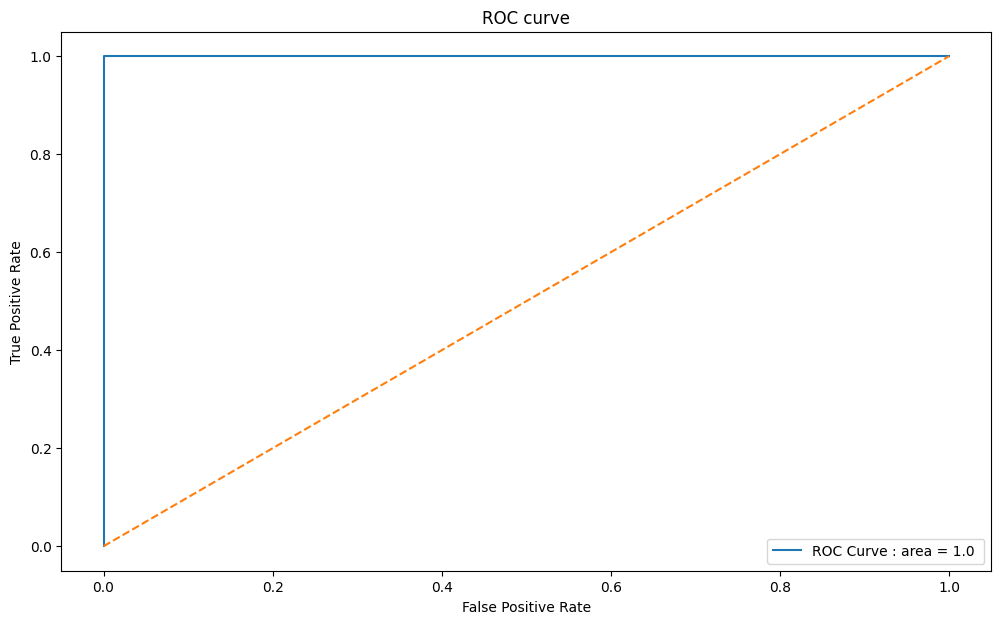

In [184]:
classifier.fit(trainX.loc[:, selected_feature], trainY.to_numpy(dtype="int"))
predictY = classifier.predict(trainX.loc[:, selected_feature])
predictY_prob = classifier.predict_proba(trainX.loc[:, selected_feature])

fpr, tpr, thresholds = roc_curve(trainY.to_numpy(dtype="int"), predictY_prob[:, 1], pos_label=1)

conf_mat = confusion_matrix(trainY.to_numpy(dtype=float), predictY.round())
print(conf_mat)

fig, axes = plt.subplots(figsize=(12, 7))
roc_auc = auc(fpr, tpr)
axes.plot(fpr, tpr, label="ROC Curve : area = {} ".format(roc_auc))
axes.plot([0, 1], [0, 1], "--")
axes.set_xlabel("False Positive Rate")
axes.set_ylabel("True Positive Rate")
axes.legend()
axes.set_title("ROC curve")
plt.show()

v. Test the classifier on the test set. Remember to break the time series in
your test set into the same number of time series into which you broke your
training set. Remember that the classifier has to be tested using the features
extracted from the test set. Compare the accuracy on the test set with the
cross-validation accuracy you obtained previously.

[[15  0]
 [ 0  4]]


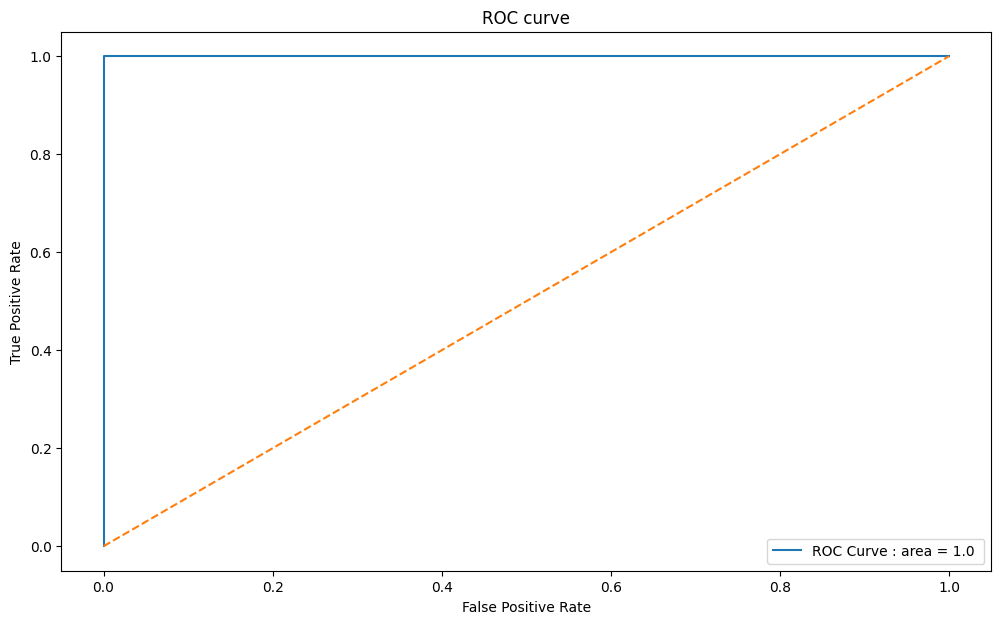

In [185]:
test_df = load_data(test_files, segment_count=1)
test_df['label'] = test_df['label'].apply(lambda x: 1 if 'bending' in x else 0)
testX, testY = test_df.iloc[:, :-1], test_df.iloc[:, -1]

predictY = classifier.predict(testX.loc[:, selected_feature])
predictY_prob = classifier.predict_proba(testX.loc[:, selected_feature])

fpr, tpr, thresholds = roc_curve(testY.to_numpy(dtype="int"), predictY_prob[:, 1], pos_label=1)

# create confusion matrix
conf_mat = confusion_matrix(testY.astype(int), predictY.astype(int))
print(conf_mat)

fig, axes = plt.subplots(figsize=(12, 7))
roc_auc = auc(fpr, tpr)
axes.plot(fpr, tpr, label="ROC Curve : area = {} ".format(roc_auc))
axes.plot([0, 1], [0, 1], "--")
axes.set_xlabel("False Positive Rate")
axes.set_ylabel("True Positive Rate")
axes.legend()
axes.set_title("ROC curve")
plt.show()

vi. Do your classes seem to be well-separated to cause instability in calculating
logistic regression parameters?

### Answer:

The statsmodels summary shows quasi-separation

```
Possibly complete quasi-separation: A fraction 0.67 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
```

vii. From the confusion matrices you obtained, do you see imbalanced classes?
If yes, build a logistic regression model based on case-control sampling and
adjust its parameters. Report the confusion matrix, ROC, and AUC of the
model.

### Answer:

Yes, there is a class imbalance in the training set since there are more True Positives than True Negatives.

In [186]:
iterateL(train_files, 5, 20, oversample=True)

Oversample the minority from 9 to 60 samples
Pair (1, 9), scores 1.0
Oversample the minority from 9 to 60 samples
Pair (2, 4), scores 0.9917
Oversample the minority from 9 to 60 samples
Pair (3, 9), scores 0.9833
Oversample the minority from 9 to 60 samples
Pair (4, 14), scores 0.9833
Oversample the minority from 9 to 60 samples
Pair (5, 4), scores 0.9917
Oversample the minority from 9 to 60 samples
Pair (6, 3), scores 0.9917
Oversample the minority from 9 to 60 samples
Pair (7, 4), scores 0.9917
Oversample the minority from 9 to 60 samples
Pair (8, 5), scores 1.0
Oversample the minority from 9 to 60 samples
Pair (9, 4), scores 1.0
Oversample the minority from 9 to 60 samples
Pair (10, 8), scores 1.0
Oversample the minority from 9 to 60 samples
Pair (11, 4), scores 1.0
Oversample the minority from 9 to 60 samples
Pair (12, 2), scores 1.0
Oversample the minority from 9 to 60 samples
Pair (13, 4), scores 1.0
Oversample the minority from 9 to 60 samples
Pair (14, 3), scores 0.9917
Oversam

In [187]:
column_names = ['# Columns: time','avg_rss12','var_rss12','avg_rss13','var_rss13','avg_rss23','var_rss23']
time_series_columns = column_names[1:]
feature_columns = ['mean', 'std', 'min', '1st_quart', 'median', '3rd_quart', 'max']

classifier, selector = LR_helper(train_files, 5, 1, oversample=True)
new_feature_columns = [f"{col}_{feat}" for col in time_series_columns for feat in feature_columns]
selected_feature = [f for i, f in enumerate(new_feature_columns) if selector.support_[i]]

selected_feature

Oversample the minority from 9 to 60 samples


['avg_rss12_mean',
 'avg_rss12_3rd_quart',
 'var_rss12_max',
 'avg_rss13_min',
 'avg_rss13_median',
 'avg_rss23_mean',
 'avg_rss23_min',
 'avg_rss23_1st_quart',
 'avg_rss23_max']

[[60  0]
 [ 0  9]]


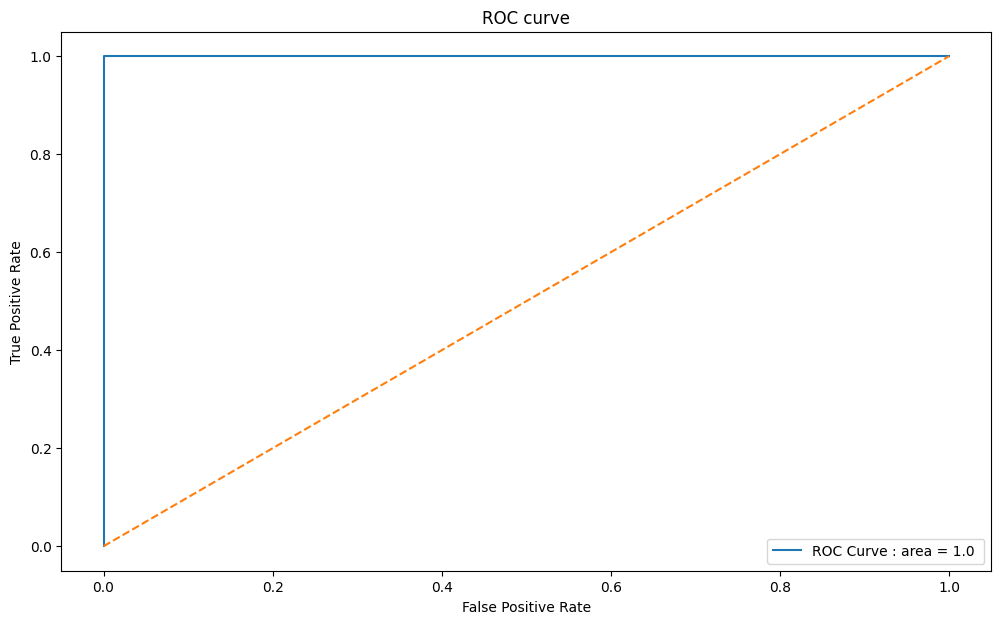

In [188]:
classifier.fit(trainX.loc[:, selected_feature], trainY.to_numpy(dtype="int"))
predictY = classifier.predict(trainX.loc[:, selected_feature])
predictY_prob = classifier.predict_proba(trainX.loc[:, selected_feature])

fpr, tpr, thresholds = roc_curve(trainY.to_numpy(dtype="int"), predictY_prob[:, 1], pos_label=1)

conf_mat = confusion_matrix(trainY.to_numpy(dtype=float), predictY.round())
print(conf_mat)

fig, axes = plt.subplots(figsize=(12, 7))
roc_auc = auc(fpr, tpr)
axes.plot(fpr, tpr, label="ROC Curve : area = {} ".format(roc_auc))
axes.plot([0, 1], [0, 1], "--")
axes.set_xlabel("False Positive Rate")
axes.set_ylabel("True Positive Rate")
axes.legend()
axes.set_title("ROC curve")
plt.show()

[[15  0]
 [ 0  4]]


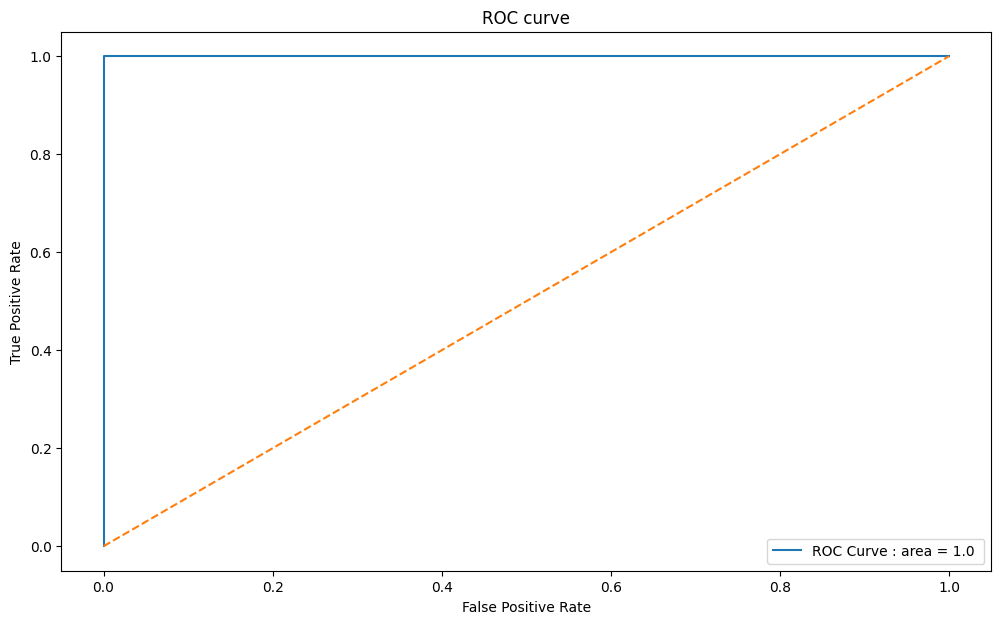

In [189]:
test_df = load_data(test_files, segment_count=1)
test_df['label'] = test_df['label'].apply(lambda x: 1 if 'bending' in x else 0)
testX, testY = test_df.iloc[:, :-1], test_df.iloc[:, -1]

predictY = classifier.predict(testX.loc[:, selected_feature])
predictY_prob = classifier.predict_proba(testX.loc[:, selected_feature])

fpr, tpr, thresholds = roc_curve(testY.to_numpy(dtype="int"), predictY_prob[:, 1], pos_label=1)

# create confusion matrix
conf_mat = confusion_matrix(testY.astype(int), predictY.astype(int))
print(conf_mat)

fig, axes = plt.subplots(figsize=(12, 7))
roc_auc = auc(fpr, tpr)
axes.plot(fpr, tpr, label="ROC Curve : area = {} ".format(roc_auc))
axes.plot([0, 1], [0, 1], "--")
axes.set_xlabel("False Positive Rate")
axes.set_ylabel("True Positive Rate")
axes.legend()
axes.set_title("ROC curve")
plt.show()

### (b) Binary Classification Using L1-penalized logistic regression

i. Repeat 2(a)iii using L1-penalized logistic regression,8 i.e. instead of using p-
values for variable selection, use L1 regularization. Note that in this problem,
you have to cross-validate for both l, the number of time series into which you
break each of your instances, and λ, the weight of L1 penalty in your logistic
regression objective function (or C, the budget). Packages usually perform
cross-validation for λ automatically.

In [190]:
def iterateLWithClf(classifier_obj, kwargs, binary_classes):
    for l in range(1, 20 + 1):
        # specify columns
        column_names = ['# Columns: time','avg_rss12','var_rss12','avg_rss13','var_rss13','avg_rss23','var_rss23']
        time_series_columns = column_names[1:]
        feature_columns = ['mean', 'std', 'min', '1st_quart', 'median', '3rd_quart', 'max']
        feature = [f"{col}_{feat}" for col in time_series_columns for feat in feature_columns]
        
        # load data with given value of l
        train_df = load_data(train_files, segment_count=l)
        test_df = load_data(test_files, segment_count=l)
        
        # relabel the instance if it is binary classification
        if binary_classes:
            test_df['label'] = test_df['label'].apply(lambda x: 1 if 'bending' in x else 0)
            train_df['label'] = train_df['label'].apply(lambda x: 1 if 'bending' in x else 0)
        
        # split feature and label
        trainX, trainY = train_df.iloc[:, :-1], train_df.iloc[:, -1]
        testX, testY = test_df.iloc[:, :-1], test_df.iloc[:, -1]
        
        # build the classifier and fit the data
        classifier = classifier_obj(**kwargs)
        classifier.fit(trainX, trainY)
        
        # calculate the scores
        train_score = classifier.score(trainX, trainY)
        test_score = classifier.score(testX, testY)
        
        print("Value of l ~ {} : train scores {}, test score {}".format(l, 
                                                     round(train_score, 4), 
                                                     round(test_score, 4)))

        
# function to plot ROC curves
def plotROC(classifier, groudTruthY, predictY_prob, title):
    fig, axes = plt.subplots(figsize=(12, 7))
    for i, c in enumerate(classifier.classes_):
        fpr, tpr, thresholds = roc_curve(groudTruthY, predictY_prob[:, i], pos_label=c)
        roc_auc = auc(fpr, tpr)
        axes.plot(fpr, tpr, label="ROC Curve of {} : area = {} ".format(c, round(roc_auc, 4)))
    axes.plot([0, 1], [0, 1], "--")
    axes.set_xlabel("False Positive Rate")
    axes.set_ylabel("True Positive Rate")
    axes.legend()
    axes.set_title("ROC curves of {}".format(title))
    plt.show()


def useOptimLonTest(l, classifier, kwargs, binary_classes):
    # specify columns
    column_names = ['# Columns: time','avg_rss12','var_rss12','avg_rss13','var_rss13','avg_rss23','var_rss23']
    time_series_columns = column_names[1:]
    feature_columns = ['mean', 'std', 'min', '1st_quart', 'median', '3rd_quart', 'max']
    feature = [f"{col}_{feat}" for col in time_series_columns for feat in feature_columns]
    
    # load data with given value of l
    train_df = load_data(train_files, segment_count=l)
    test_df = load_data(test_files, segment_count=l)
    
    # relabel the instance if it is binary classification
    if binary_classes:
        test_df['label'] = test_df['label'].apply(lambda x: 1 if 'bending' in x else 0)
        train_df['label'] = train_df['label'].apply(lambda x: 1 if 'bending' in x else 0)
    
    # split feature and label
    trainX, trainY = train_df.iloc[:, :-1], train_df.iloc[:, -1]
    testX, testY = test_df.iloc[:, :-1], test_df.iloc[:, -1]
    
    # the new constructed model
    classifier = classifier(**kwargs)
    classifier.fit(trainX, trainY)
    
    # get prediction probability for both train and test, this is used to get ROC curve
    train_predictY_prob = classifier.predict_proba(trainX)
    predictY_prob = classifier.predict_proba(testX)
    
    # get prediction of test set and its confusion matrix
    predictY = classifier.predict(testX)
    conf_mat = confusion_matrix(testY, predictY)
    print("Confusion matrix on test set:\n{}".format(conf_mat))
    
    # plot ROC for multiple classes
    plotROC(classifier, trainY, train_predictY_prob, "Train Set")
    plotROC(classifier, testY, predictY_prob, "Test Set")

In [191]:
kwargs = {
    'penalty' : 'l1', 
    'max_iter' : 100,
    'scoring' : 'accuracy',
    'cv' : 5,
    'random_state' : 69,
    'solver' : 'liblinear'
}

iterateLWithClf(LogisticRegressionCV, kwargs, binary_classes=True)

/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Value of l ~ 1 : train scores 1.0, test score 1.0


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Value of l ~ 2 : train scores 0.9565, test score 0.9474


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

...

/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Value of l ~ 18 : train scores 1.0, test score 0.9474


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Value of l ~ 19 : train scores 1.0, test score 0.9474
Value of l ~ 20 : train scores 1.0, test score 0.9474


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Confusion matrix on test set:
[[15  0]
 [ 0  4]]


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


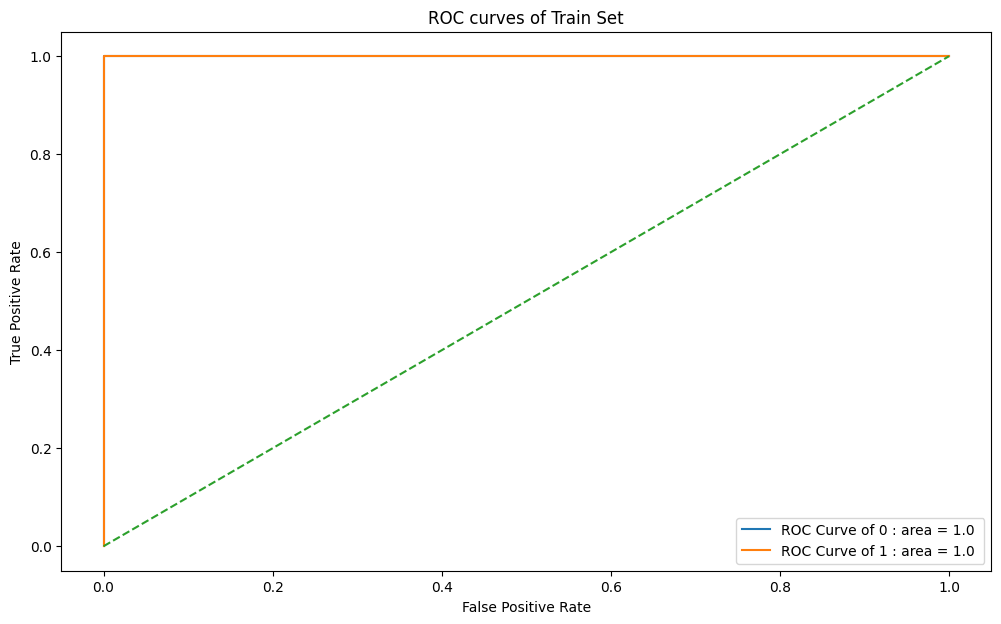

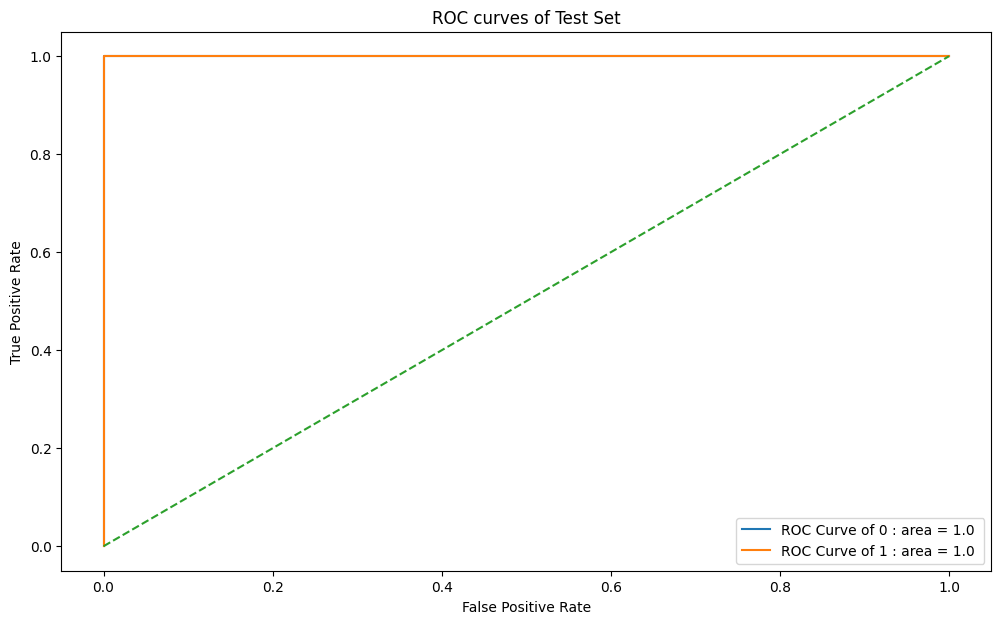

In [192]:
kwargs = {
    'penalty' : 'l1', 
    'max_iter' : 100, 
    'solver' : 'liblinear'
}

useOptimLonTest(1, LogisticRegression, kwargs, binary_classes=True)

ii. Compare the L1-penalized with variable selection using p-values. Which one
performs better? Which one is easier to implement?

### Answer:

- L1-penalized model has a better performance on cross validation and a pretty good score (1.0 accuracy) for test set as well.
- The L1-regularization should be easier for implementation because, unlike selection using p-value, we do not need to mannually select the features after an intensive computing of p-values. The sharper edges of L1 constrain helps to select features.

### (c) Multi-class Classification (The Realistic Case)

i. Find the best l in the same way as you found it in 2(b)i to build an L1-
penalized multinomial regression model to classify all activities in your train-
ing set.10 Report your test error. Research how confusion matrices and ROC
curves are defined for multiclass classification and show them for this problem
if possible.

In [193]:
kwargs = {
    'penalty' : 'l1', 
    'max_iter' : 100,
    'cv' : 5,
    'random_state' : 69,
    'solver' : 'saga'
}

iterateLWithClf(LogisticRegressionCV, kwargs, binary_classes=False)

/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Value of l ~ 1 : train scores 1.0, test score 0.8947


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Value of l ~ 2 : train scores 1.0, test score 0.9474


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

...

/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Value of l ~ 19 : train scores 1.0, test score 0.8421


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Value of l ~ 20 : train scores 1.0, test score 0.7895


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Confusion matrix on test set:
[[2 0 0 0 0 0 0]
 [0 1 1 0 0 0 0]
 [0 0 3 0 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 2 1 0]
 [0 0 0 0 0 3 0]
 [0 0 0 0 0 0 3]]


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


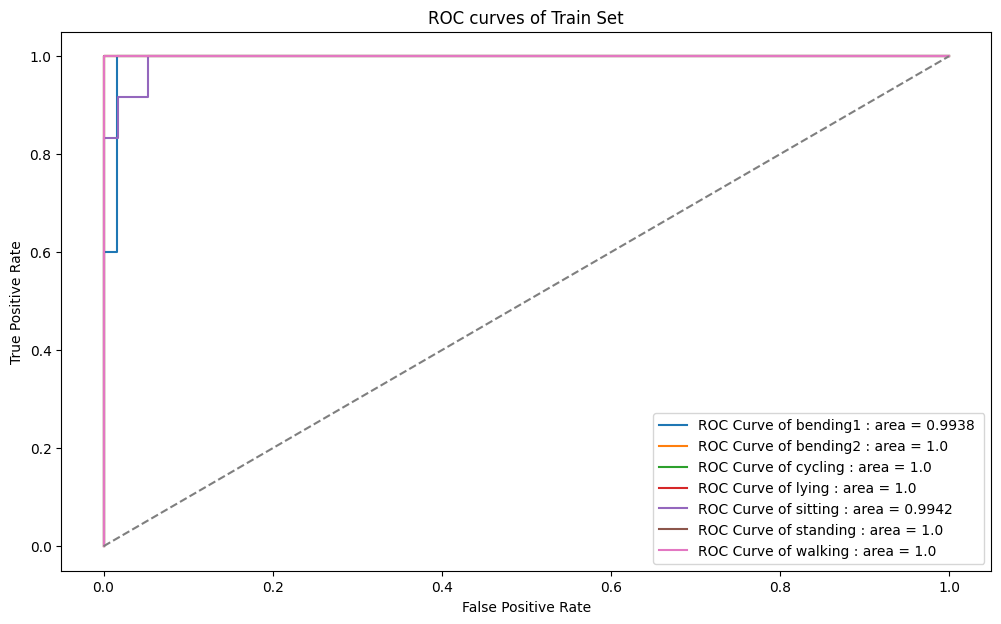

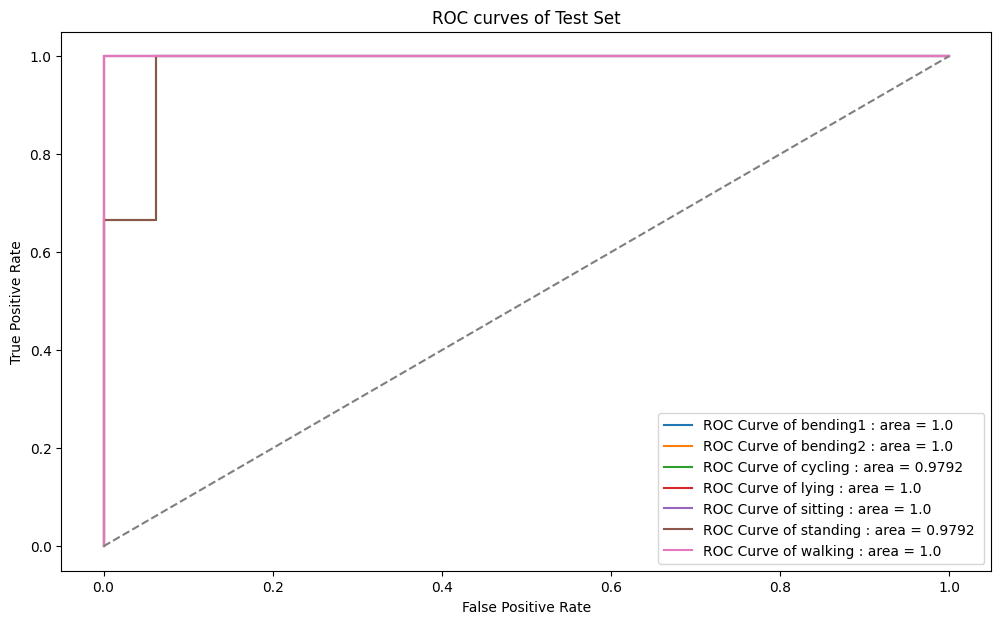

In [194]:
kwargs = {
    'penalty' : 'l1', 
    'max_iter' : 100,  
    'solver' : 'saga'
}

useOptimLonTest(2, LogisticRegression, kwargs, binary_classes=False)

ii. Repeat 2(c)i using a Na¨ıve Bayes’ classifier. Use both Gaussian and Multi-
nomial priors and compare the results.

In [195]:
iterateLWithClf(GaussianNB, {}, binary_classes=False)

Value of l ~ 1 : train scores 1.0, test score 0.8947
Value of l ~ 2 : train scores 1.0, test score 0.6316
Value of l ~ 3 : train scores 0.9855, test score 0.7368
Value of l ~ 4 : train scores 1.0, test score 0.7895
Value of l ~ 5 : train scores 0.9855, test score 0.7895
Value of l ~ 6 : train scores 0.971, test score 0.6316
Value of l ~ 7 : train scores 1.0, test score 0.7368
Value of l ~ 8 : train scores 0.9855, test score 0.7368
Value of l ~ 9 : train scores 1.0, test score 0.6842
Value of l ~ 10 : train scores 1.0, test score 0.7895
Value of l ~ 11 : train scores 0.9855, test score 0.6842
Value of l ~ 12 : train scores 1.0, test score 0.6316
Value of l ~ 13 : train scores 1.0, test score 0.7368
Value of l ~ 14 : train scores 1.0, test score 0.5789
Value of l ~ 15 : train scores 1.0, test score 0.5789
Value of l ~ 16 : train scores 1.0, test score 0.5263
Value of l ~ 17 : train scores 1.0, test score 0.5263
Value of l ~ 18 : train scores 1.0, test score 0.6842
Value of l ~ 19 : train

Confusion matrix on test set:
[[2 0 0 0 0 0 0]
 [0 2 0 0 0 0 0]
 [0 0 3 0 0 0 0]
 [0 0 0 2 1 0 0]
 [0 0 0 0 3 0 0]
 [0 0 0 0 1 2 0]
 [0 0 0 0 0 0 3]]


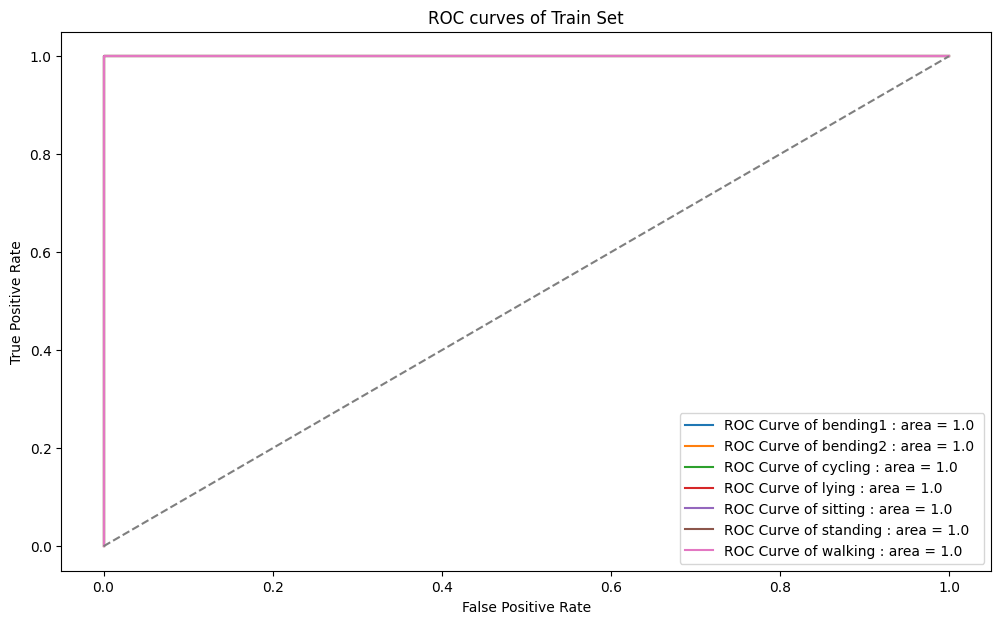

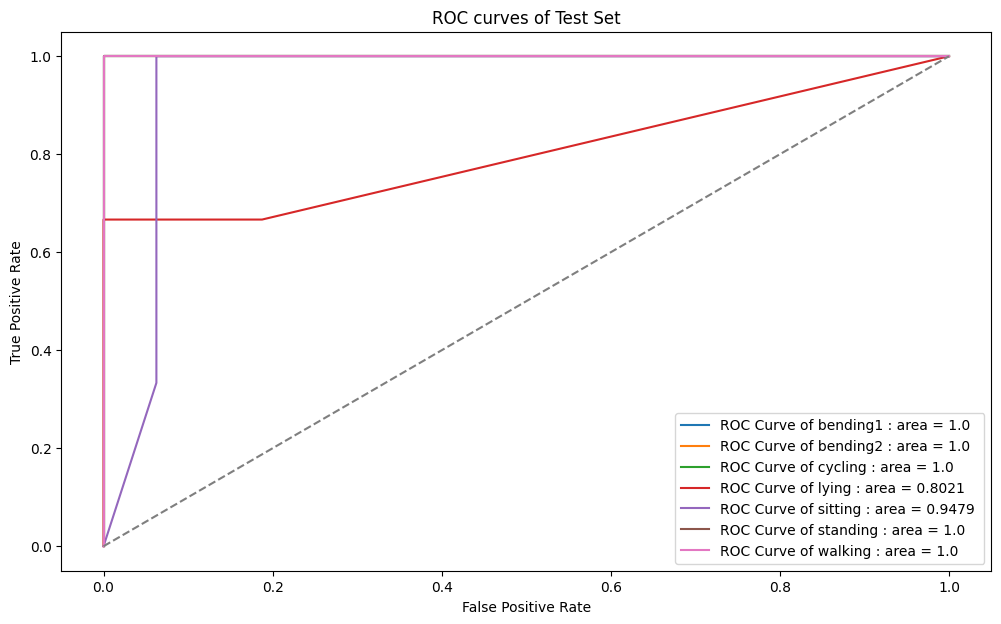

In [196]:
useOptimLonTest(1, GaussianNB, {}, binary_classes=False)

In [197]:
iterateLWithClf(MultinomialNB, {}, binary_classes=False)

Value of l ~ 1 : train scores 0.9275, test score 0.8947
Value of l ~ 2 : train scores 0.8841, test score 0.7368
Value of l ~ 3 : train scores 0.8986, test score 0.7895
Value of l ~ 4 : train scores 0.913, test score 0.7895
Value of l ~ 5 : train scores 0.9275, test score 0.7368
Value of l ~ 6 : train scores 0.9565, test score 0.7368
Value of l ~ 7 : train scores 0.942, test score 0.7368
Value of l ~ 8 : train scores 0.942, test score 0.7368
Value of l ~ 9 : train scores 0.942, test score 0.7368
Value of l ~ 10 : train scores 0.942, test score 0.7368
Value of l ~ 11 : train scores 0.942, test score 0.7895
Value of l ~ 12 : train scores 0.942, test score 0.7368
Value of l ~ 13 : train scores 0.942, test score 0.7895
Value of l ~ 14 : train scores 0.942, test score 0.7895
Value of l ~ 15 : train scores 0.942, test score 0.7895
Value of l ~ 16 : train scores 0.942, test score 0.7895
Value of l ~ 17 : train scores 0.942, test score 0.8421
Value of l ~ 18 : train scores 0.942, test score 0.8

Confusion matrix on test set:
[[2 0 0 0 0 0 0]
 [0 2 0 0 0 0 0]
 [0 0 3 0 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 2 1 0]
 [0 0 0 1 0 2 0]
 [0 0 0 0 0 0 3]]


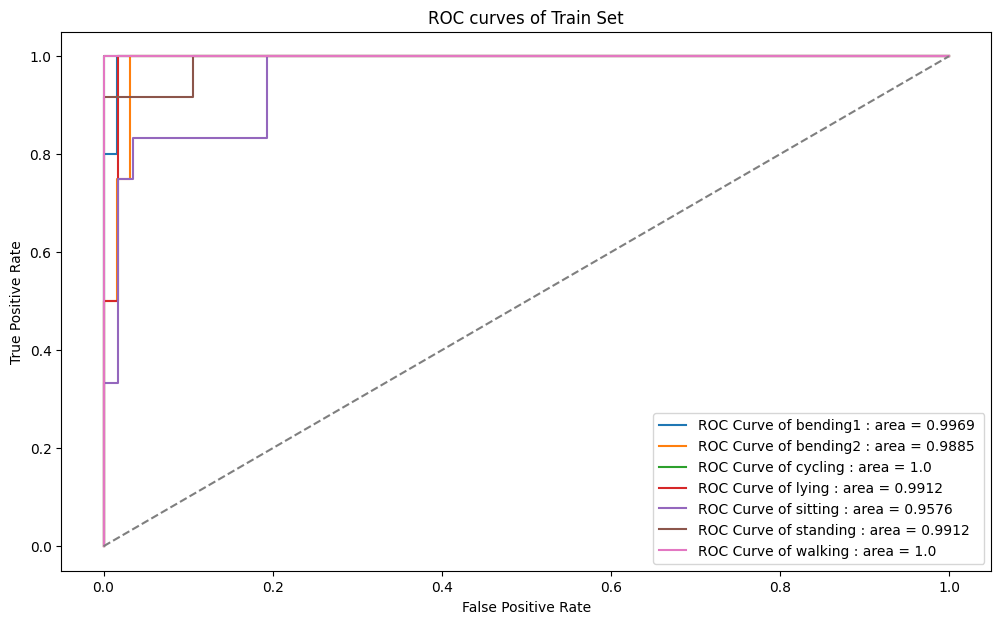

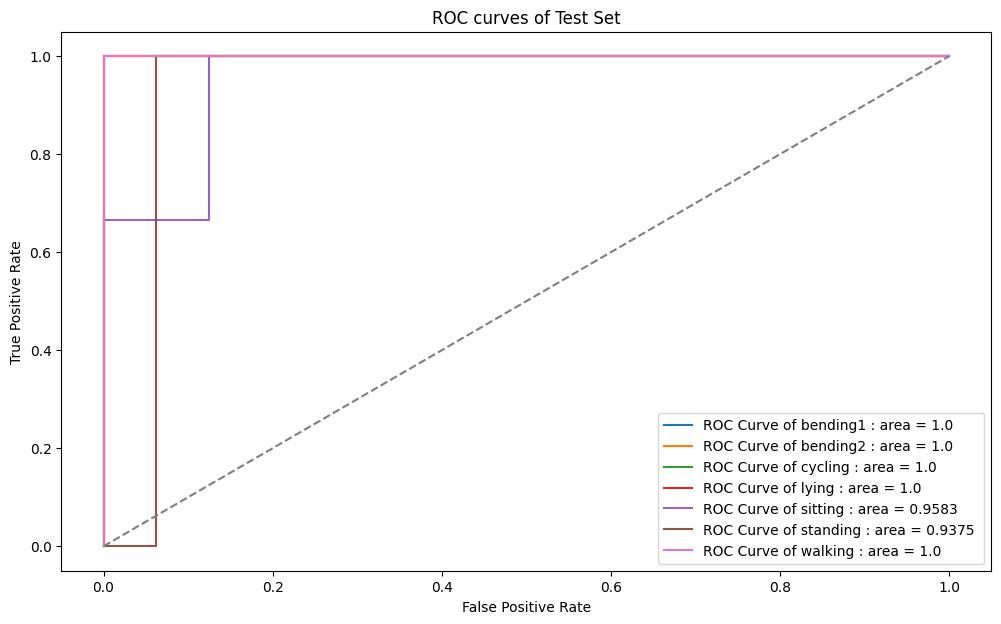

In [198]:
useOptimLonTest(1, MultinomialNB, {}, binary_classes=False)

iii. Which method is better for multi-class classification in this problem?

### Answer:

From the reported results above, the three models have the same error rate on test set (2 misclassified samples). However, we can see that the logistic regression has a better ROC curves whose AUC are larger for all classes. That means the logistic regression has a relatively better classification performance for this dataset.

## Conceptual Questions

### ISLR 4.8.3

This problem relates to the QDA model, in which the observations
within each class are drawn from a normal distribution with a class-
specific mean vector and a class specific covariance matrix. We con
sider the simple case where p= 1; i.e. there is only one feature.

Suppose that we have K classes, and that if an observation belongs
to the kth class then X comes from a one-dimensional normal dis-
tribution, $$X∼N(µ_k,σ^2_{
k})$$. 

Recall that the density function for the
one-dimensional normal distribution is given in (4.16). Prove that in
this case, the Bayes classifier is not linear. Argue that it is in fact
quadratic.

Hint: For this problem, you should follow the arguments laid out in
Section 4.4.1, but without making the assumption that $$σ^2_{
1} =
...
= σ^2_{
K}$$.

### Answer:

We have

$$\delta_{k}(x) = log(\pi_{k}) - log(2*\pi)/2 - log(\sigma_{k}) - \frac{(x-\mu_{k})^2}{2\sigma^2}$$

This is a quadratic equation in x with coefficient of the square term being $$\frac{1}{2\sigma^2}$$

When we are determining the decision boundary between class k and class l, we can say

$$\delta_{k}(x) = \delta_{l}(x)$$

This will have quadratic terms on both sides with the coefficients $$\frac{1}{2\sigma_{k}^2}$$ and $$\frac{1}{2\sigma_{l}^2}$$.

Assuming that the variances are not equal for all the classes, we can say that the coefficient of the square term will not be zero and hence the Bayes classifier is quadratic.

### ISLR 4.8.7

Suppose that we wish to predict whether a given stock will issue a
dividend this year (“Yes” or “No”) based on X, last year’s percent
profit. We examine a large number of companies and discover that the
¯
mean value of X for companies that issued a dividend was
X = 10,
¯
while the mean for those that didn’t was
X = 0. In addition, the
variance of X for these two sets of companies was ˆ σ2 = 36. Finally,
80 % of companies issued dividends. Assuming that X follows a nor
mal distribution, predict the probability that a company will issue
a dividend this year given that its percentage profit was X = 4 last
year.

Hint: Recall that the density function for a normal random variable
is $$f(x) = \frac{1}{
\sqrt{2πσ^2}} e^{−\frac{(x−µ)^2}{2σ^
2}}$$. You will need to use Bayes’ theorem.


### Answer:

We have

$$\pi_{Y} = 0.8$$
$$\pi_{N} = 0.2$$
$$\mu_{Y} = 10$$
$$\mu_{N} = 0$$
$$\sigma^2 = 36$$

Applying the Bayes theorem,

$$P(Y | X = 4) = \frac{\pi_{Y}*f_{Y}(4)}{\pi_{Y}*f_{Y}(4) + \pi_{N}*f_{N}(4)}$$

$$ = \frac{0.8*e^{-\frac{(4-10)^2}{2*36}}}{0.8*e^{-\frac{(4-10)^2}{2*36}} + 0.2*e^{-\frac{(4-0)^2}{2*36}}}$$

$$ = 0.752$$

So the probability that the company will issue a dividend this year given that its percentage profit was 4 last year is approximately 75\%.